# Aim of this notebook
The goal of this note book is to automate the FAIR assesment of mutliple DOIs through the [FAIR-Checker tool](https://fair-checker.france-bioinformatique.fr). 
All resulst are stored in a matrix and serialized into a CSV file. Scores can be interpreted as follows: 
 - 0 -> `failure`
 - 1 -> `weak` assesment
 - 2 -> `strong` assesment

To run this notebook you just need the `requests` and `pandas` python libraries. 

The FAIR-Checker API is better described at https://fair-checker.france-bioinformatique.fr/swagger 

Please report any issue at https://github.com/IFB-ElixirFr/fair-checker/issues or contact alban.gaignard@univ-nantes.fr. 

In [2]:
import time
import requests
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

## Input dataset

In [3]:
DOIs = [
    "https://doi.org/10.60641/91cv-vn58",
    "https://doi.org/10.48550/arxiv.2405.15830",
    "https://doi.org/10.5281/zenodo.6278497",
]

datacite_prefix = "https://api.datacite.org/application/vnd.schemaorg.ld+json/"

DOIs_datacite_jsonld = []
for doi in DOIs:
    # Replace the DOI prefix with the DataCite JSON-LD endpoint
    if doi.startswith("https://doi.org/"):
        DOIs_datacite_jsonld.append(doi.replace("https://doi.org/", datacite_prefix))

DOIs += DOIs_datacite_jsonld
print(DOIs)

['https://doi.org/10.60641/91cv-vn58', 'https://doi.org/10.48550/arxiv.2405.15830', 'https://doi.org/10.5281/zenodo.6278497', 'https://api.datacite.org/application/vnd.schemaorg.ld+json/10.60641/91cv-vn58', 'https://api.datacite.org/application/vnd.schemaorg.ld+json/10.48550/arxiv.2405.15830', 'https://api.datacite.org/application/vnd.schemaorg.ld+json/10.5281/zenodo.6278497']


In [15]:
FC_all_metrics_url = "https://fair-checker.france-bioinformatique.fr/api/check/legacy/metrics_all"

## FAIR assesment over all inputs 

In [18]:
from json import JSONDecodeError

df = pd.DataFrame()
rows = []

for u in DOIs:
    start = time.time()
    res = requests.get(url=FC_all_metrics_url, params={"url": u})
    eval_in_sec = time.time() - start
    
    try: 
        evaluations = res.json()
        row = {"URL": u}
    
        # iterating over all evaluation results
        for e in evaluations:
            row[e["metric"]] = int(e["score"])
        # row["duration (s)"] = round(eval_in_sec, 2)
        print(row)
        rows.append(row)
    except JSONDecodeError as error:
        print("Cannot get FAIR assesment for "+u)
        

{'URL': 'https://doi.org/10.60641/91cv-vn58', 'F1A': 2, 'F1B': 0, 'F2A': 1, 'F2B': 2, 'A1.1': 2, 'A1.2': 0, 'I1': 1, 'I2': 2, 'I3': 0, 'R1.1': 0, 'R1.2': 0, 'R1.3': 2}
{'URL': 'https://doi.org/10.48550/arxiv.2405.15830', 'F1A': 2, 'F1B': 0, 'F2A': 1, 'F2B': 1, 'A1.1': 2, 'A1.2': 0, 'I1': 1, 'I2': 1, 'I3': 0, 'R1.1': 0, 'R1.2': 0, 'R1.3': 1}
{'URL': 'https://doi.org/10.5281/zenodo.6278497', 'F1A': 2, 'F1B': 2, 'F2A': 1, 'F2B': 1, 'A1.1': 2, 'A1.2': 2, 'I1': 1, 'I2': 1, 'I3': 2, 'R1.1': 2, 'R1.2': 2, 'R1.3': 1}
{'URL': 'https://api.datacite.org/application/vnd.schemaorg.ld+json/10.60641/91cv-vn58', 'F1A': 2, 'F1B': 0, 'F2A': 1, 'F2B': 1, 'A1.1': 2, 'A1.2': 2, 'I1': 1, 'I2': 1, 'I3': 2, 'R1.1': 2, 'R1.2': 2, 'R1.3': 1}
{'URL': 'https://api.datacite.org/application/vnd.schemaorg.ld+json/10.48550/arxiv.2405.15830', 'F1A': 2, 'F1B': 2, 'F2A': 1, 'F2B': 2, 'A1.1': 2, 'A1.2': 2, 'I1': 1, 'I2': 2, 'I3': 0, 'R1.1': 2, 'R1.2': 2, 'R1.3': 2}
{'URL': 'https://api.datacite.org/application/vnd.schema

## Evaluation matrix

In [20]:
from IPython.display import display, Markdown
df = pd.DataFrame.from_records(rows)

df["F_score"] = df.apply(
    lambda row: round((row["F1A"] + row["F1B"] + row["F2A"] + row["F2B"]) * 100 / 8, 1),
    axis=1,
)
df["A_score"] = df.apply(
    lambda row: round((row["A1.1"] + row["A1.2"]) * 100 / 4, 1), axis=1
)
df["I_score"] = df.apply(
    lambda row: round((row["I1"] + row["I2"] + row["I3"]) * 100 / 6, 1), axis=1
)
df["R_score"] = df.apply(
    lambda row: round((row["R1.1"] + row["R1.2"] + row["R1.3"]) * 100 / 6, 1), axis=1
)
# df['FAIR_score'] = df.apply(lambda row: round((row["F_score"] + row["A_score"] + row["I_score"] + row["R_score"])/4, 1), axis = 1)
df["FAIR_score"] = df.apply(
    lambda row: round(
        (
            row["F1A"]
            + row["F1B"]
            + row["F2A"]
            + row["F2B"]
            + row["A1.1"]
            + row["A1.2"]
            + row["I1"]
            + row["I2"]
            + row["I3"]
            + row["R1.1"]
            + row["R1.2"]
            + row["R1.3"]
        )
        * 100
        / 24,
        1,
    ),
    axis=1,
)

df.to_csv("fc_evals-dois-2025.csv")


md = df.to_markdown()
display(Markdown(md))

|    | URL                                                                                  |   F1A |   F1B |   F2A |   F2B |   A1.1 |   A1.2 |   I1 |   I2 |   I3 |   R1.1 |   R1.2 |   R1.3 |   F_score |   A_score |   I_score |   R_score |   FAIR_score |
|---:|:-------------------------------------------------------------------------------------|------:|------:|------:|------:|-------:|-------:|-----:|-----:|-----:|-------:|-------:|-------:|----------:|----------:|----------:|----------:|-------------:|
|  0 | https://doi.org/10.60641/91cv-vn58                                                   |     2 |     0 |     1 |     2 |      2 |      0 |    1 |    2 |    0 |      0 |      0 |      2 |      62.5 |        50 |      50   |      33.3 |         50   |
|  1 | https://doi.org/10.48550/arxiv.2405.15830                                            |     2 |     0 |     1 |     1 |      2 |      0 |    1 |    1 |    0 |      0 |      0 |      1 |      50   |        50 |      33.3 |      16.7 |         37.5 |
|  2 | https://doi.org/10.5281/zenodo.6278497                                               |     2 |     2 |     1 |     1 |      2 |      2 |    1 |    1 |    2 |      2 |      2 |      1 |      75   |       100 |      66.7 |      83.3 |         79.2 |
|  3 | https://api.datacite.org/application/vnd.schemaorg.ld+json/10.60641/91cv-vn58        |     2 |     0 |     1 |     1 |      2 |      2 |    1 |    1 |    2 |      2 |      2 |      1 |      50   |       100 |      66.7 |      83.3 |         70.8 |
|  4 | https://api.datacite.org/application/vnd.schemaorg.ld+json/10.48550/arxiv.2405.15830 |     2 |     2 |     1 |     2 |      2 |      2 |    1 |    2 |    0 |      2 |      2 |      2 |      87.5 |       100 |      50   |     100   |         83.3 |
|  5 | https://api.datacite.org/application/vnd.schemaorg.ld+json/10.5281/zenodo.6278497    |     2 |     2 |     1 |     2 |      2 |      2 |    1 |    2 |    2 |      2 |      2 |      2 |      87.5 |       100 |      83.3 |     100   |         91.7 |

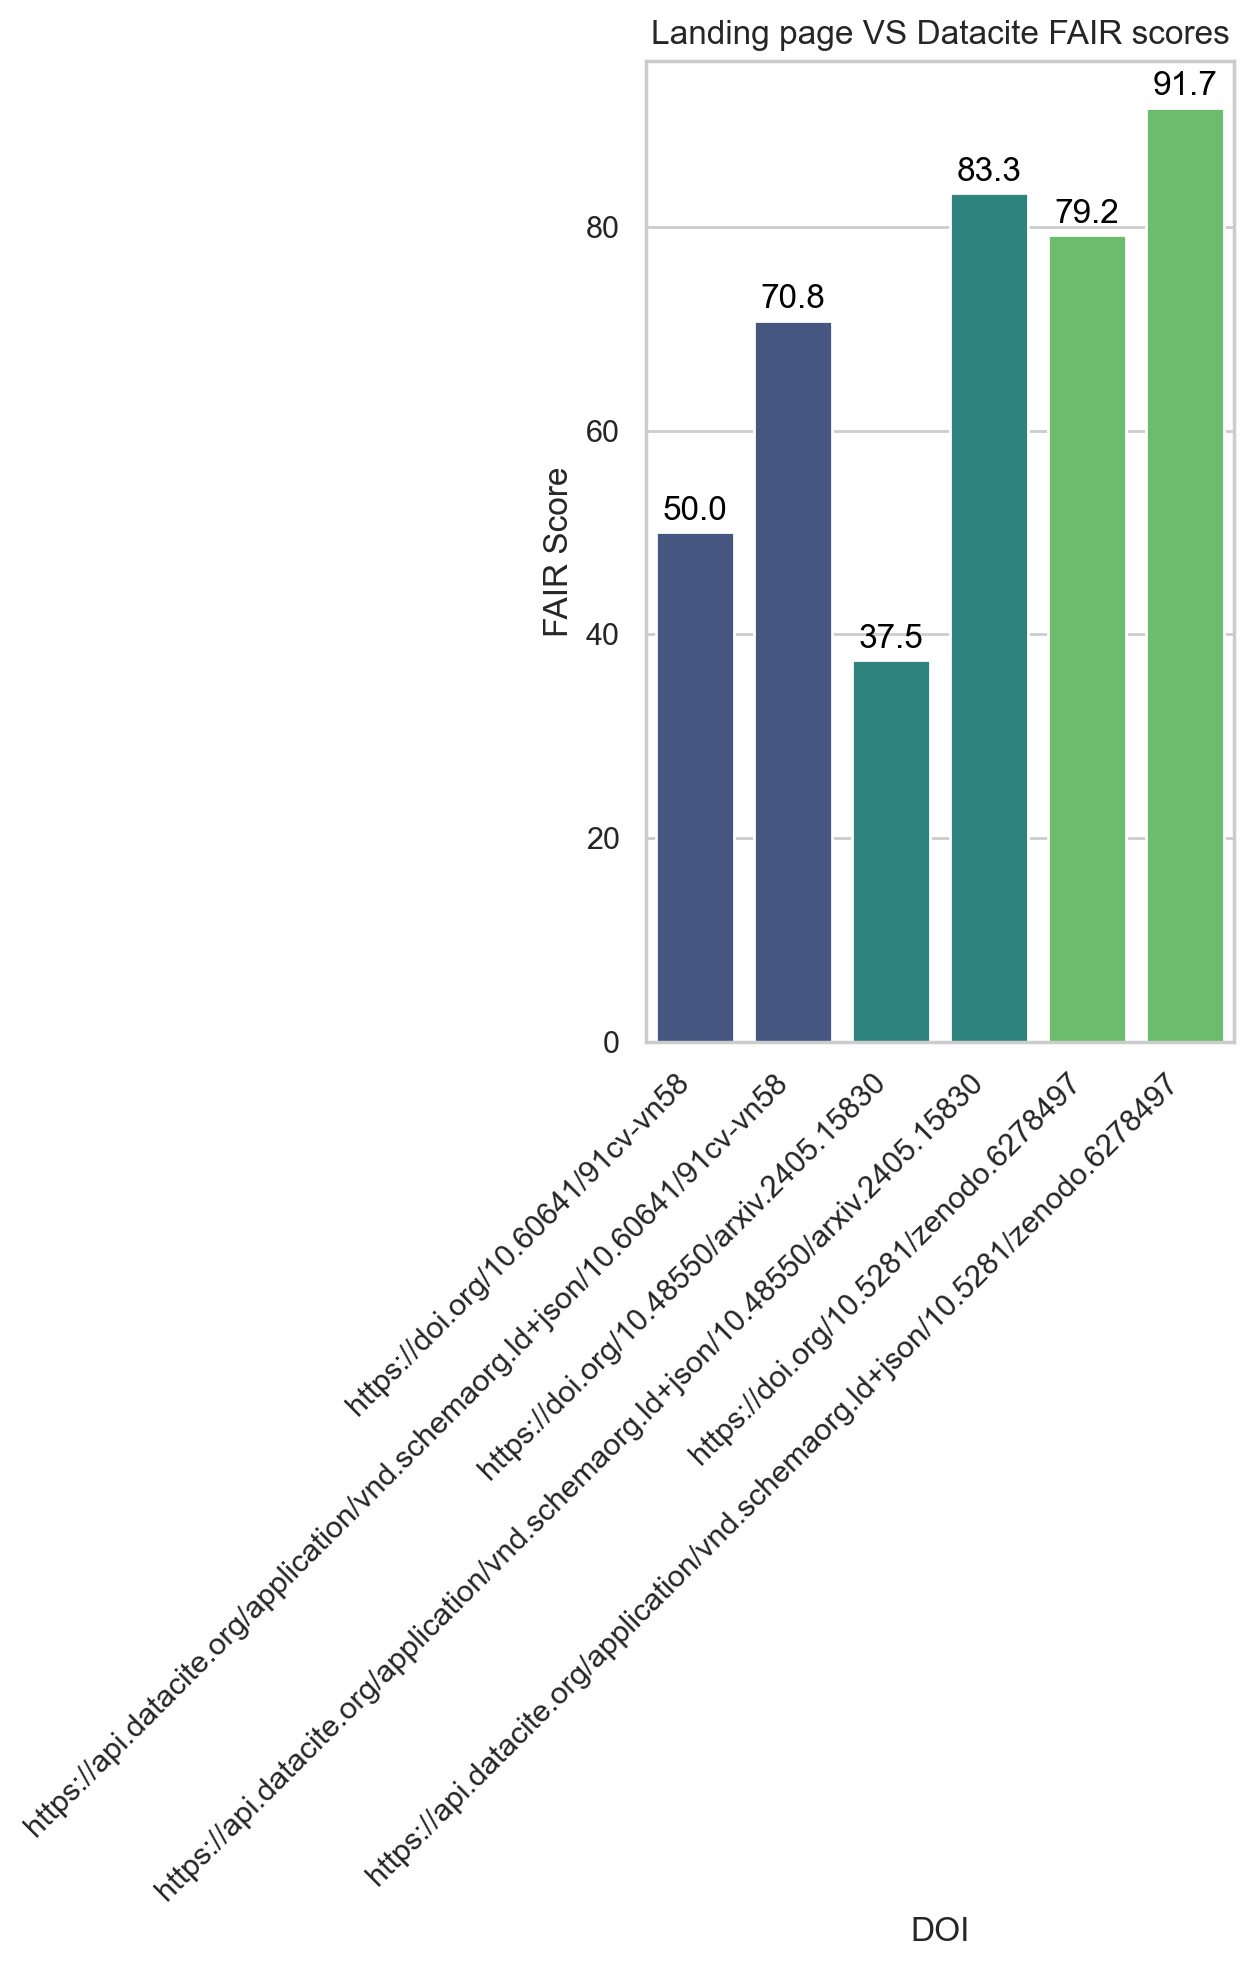

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns 


df = pd.read_csv("fc_evals-dois-2025.csv")

# group by pair or URLs ending with the same DOI
df["DOI"] = df["URL"].apply(lambda x: x.split("/")[-1])
df = df.sort_values(by="DOI")
df = df.reset_index(drop=True)

# plot with seaborn a bar plot for all FAIR scores of the DOIs
plt.figure(figsize=(6, 10))
plt.rcParams["figure.dpi"] = 200
plt.rcParams["font.size"] = 8

sns.set_theme(style="whitegrid")
sns.barplot(data=df, x="URL", y="FAIR_score", hue="DOI", palette="viridis", legend=False)

# annotate the bars with the FAIR score
for index, row in df.iterrows():
    plt.text(
        index,
        row["FAIR_score"] + 0.5,
        f"{row['FAIR_score']}",
        color="black",
        ha="center",
        va="bottom",
    )   

plt.xticks(rotation=45, ha="right")
plt.title(f"Landing page VS Datacite FAIR scores")
plt.xlabel("DOI")
plt.ylabel("FAIR Score")
plt.tight_layout()


plt.savefig("fair_scores_dois.png", dpi=300)
plt.show()

In [43]:
df

,Unnamed: 0,URL,F1A,F1B,F2A,F2B,A1.1,A1.2,I1,I2,I3,R1.1,R1.2,R1.3,F_score,A_score,I_score,R_score,FAIR_score,DOI
0,0,https://doi.org/10.60641/91cv-vn58,2,0,1,2,2,0,1,2,0,0,0,2,62.5,50.0,50.0,33.3,50.0,91cv-vn58
1,3,https://api.datacite.org/application/vnd.schem...,2,0,1,1,2,2,1,1,2,2,2,1,50.0,100.0,66.7,83.3,70.8,91cv-vn58
2,1,https://doi.org/10.48550/arxiv.2405.15830,2,0,1,1,2,0,1,1,0,0,0,1,50.0,50.0,33.3,16.7,37.5,arxiv.2405.15830
3,4,https://api.datacite.org/application/vnd.schem...,2,2,1,2,2,2,1,2,0,2,2,2,87.5,100.0,50.0,100.0,83.3,arxiv.2405.15830
4,2,https://doi.org/10.5281/zenodo.6278497,2,2,1,1,2,2,1,1,2,2,2,1,75.0,100.0,66.7,83.3,79.2,zenodo.6278497
5,5,https://api.datacite.org/application/vnd.schem...,2,2,1,2,2,2,1,2,2,2,2,2,87.5,100.0,83.3,100.0,91.7,zenodo.6278497


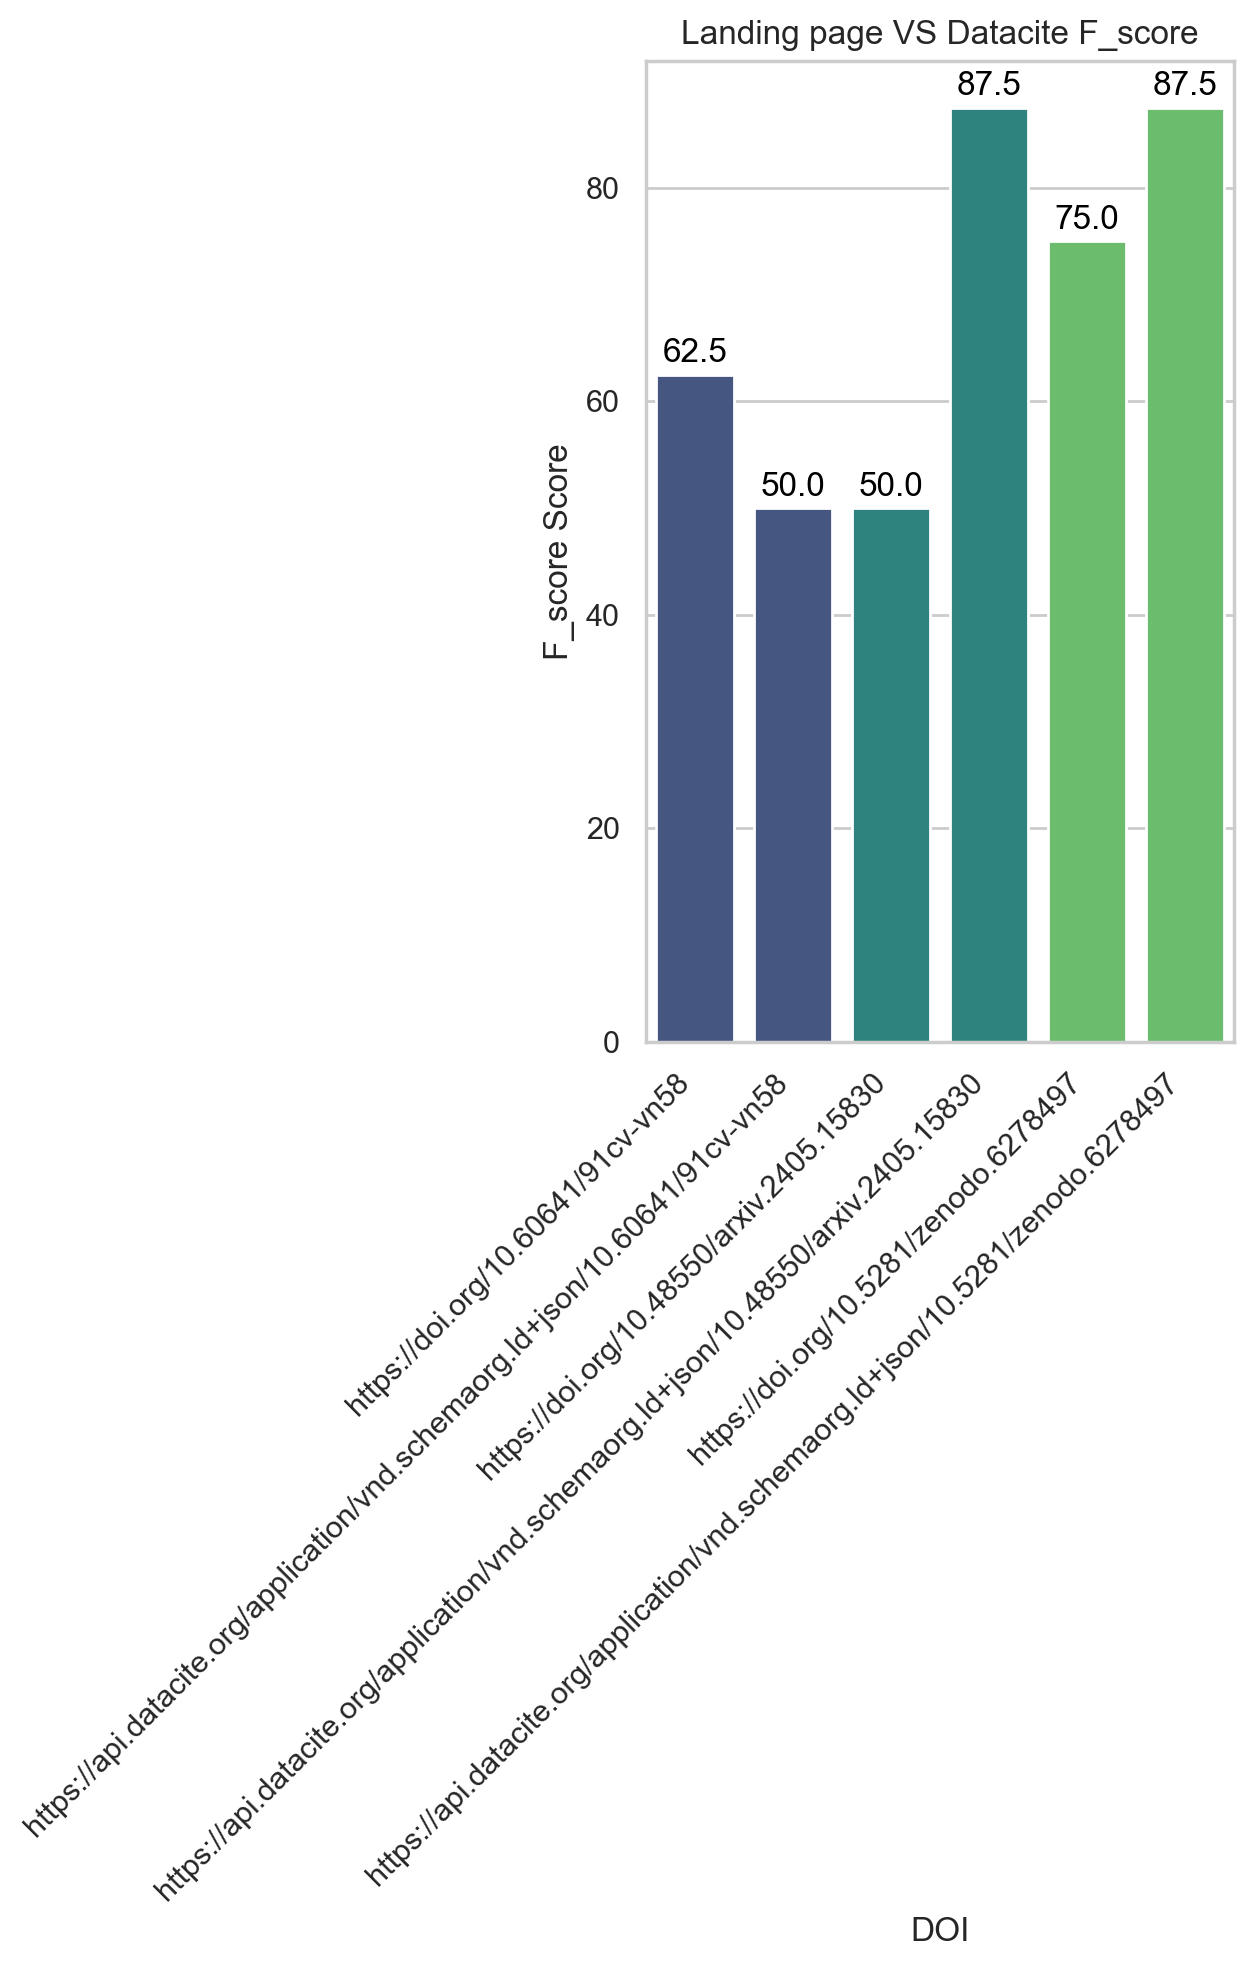

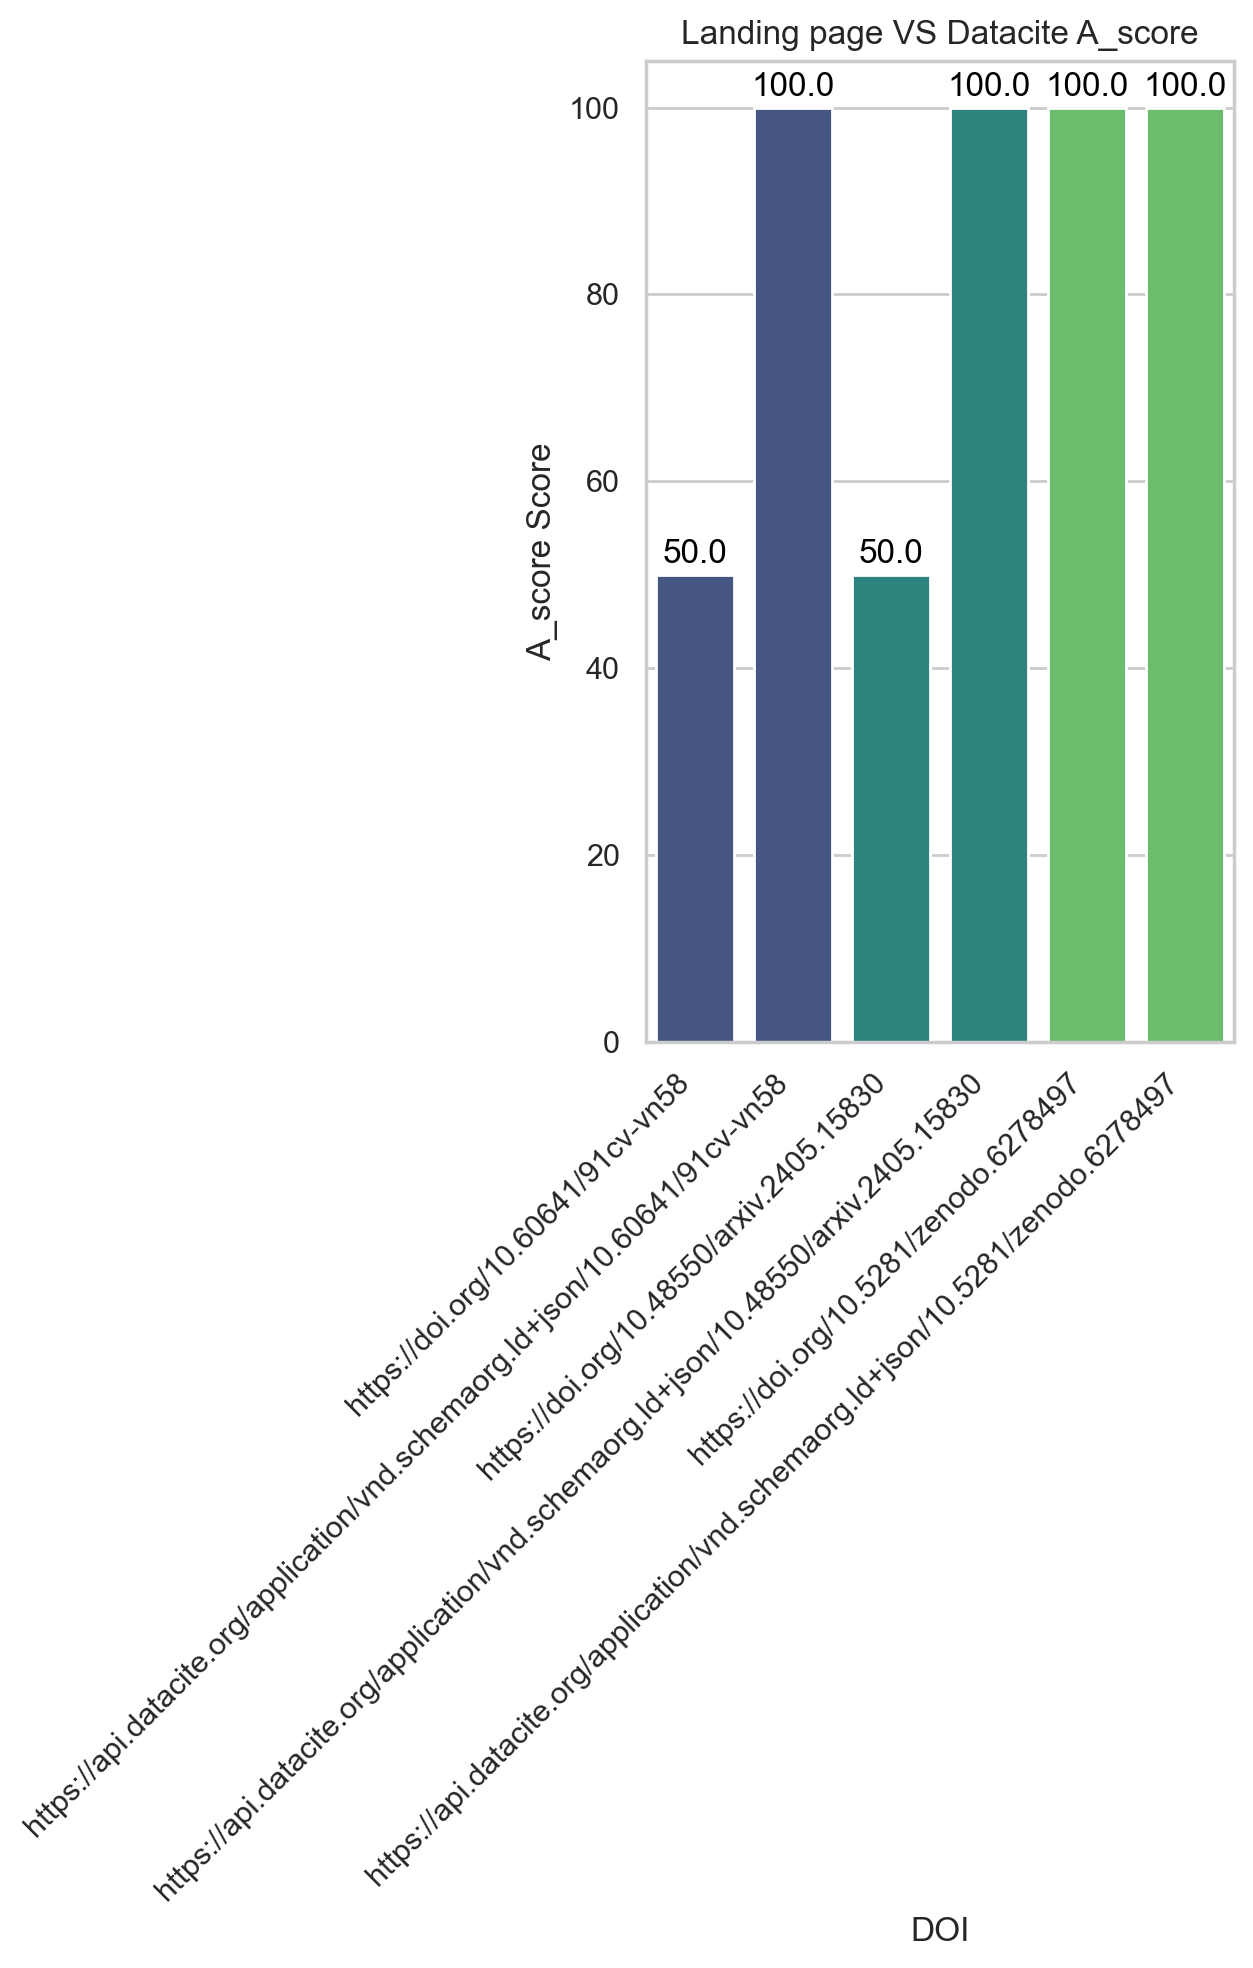

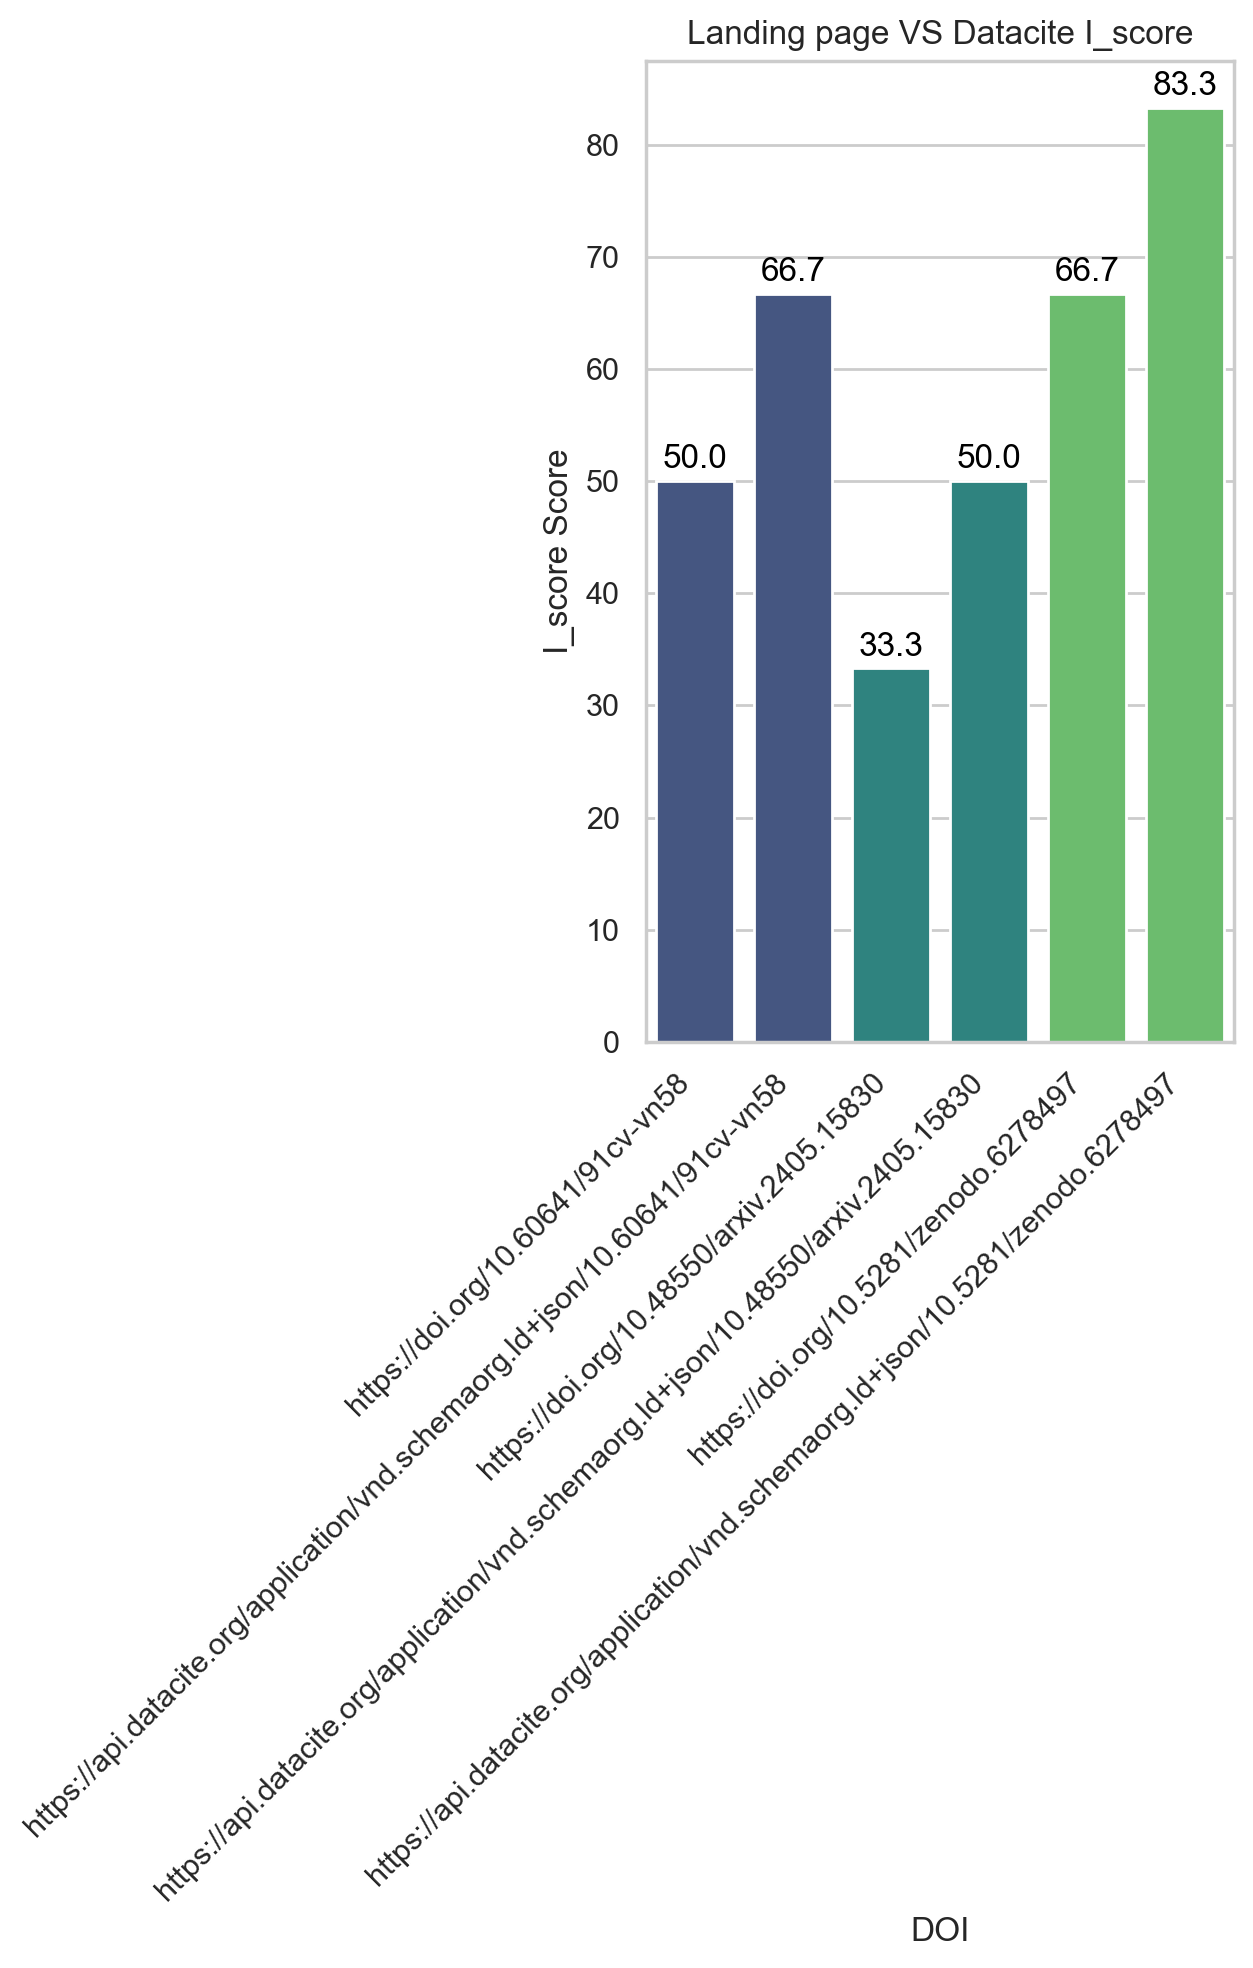

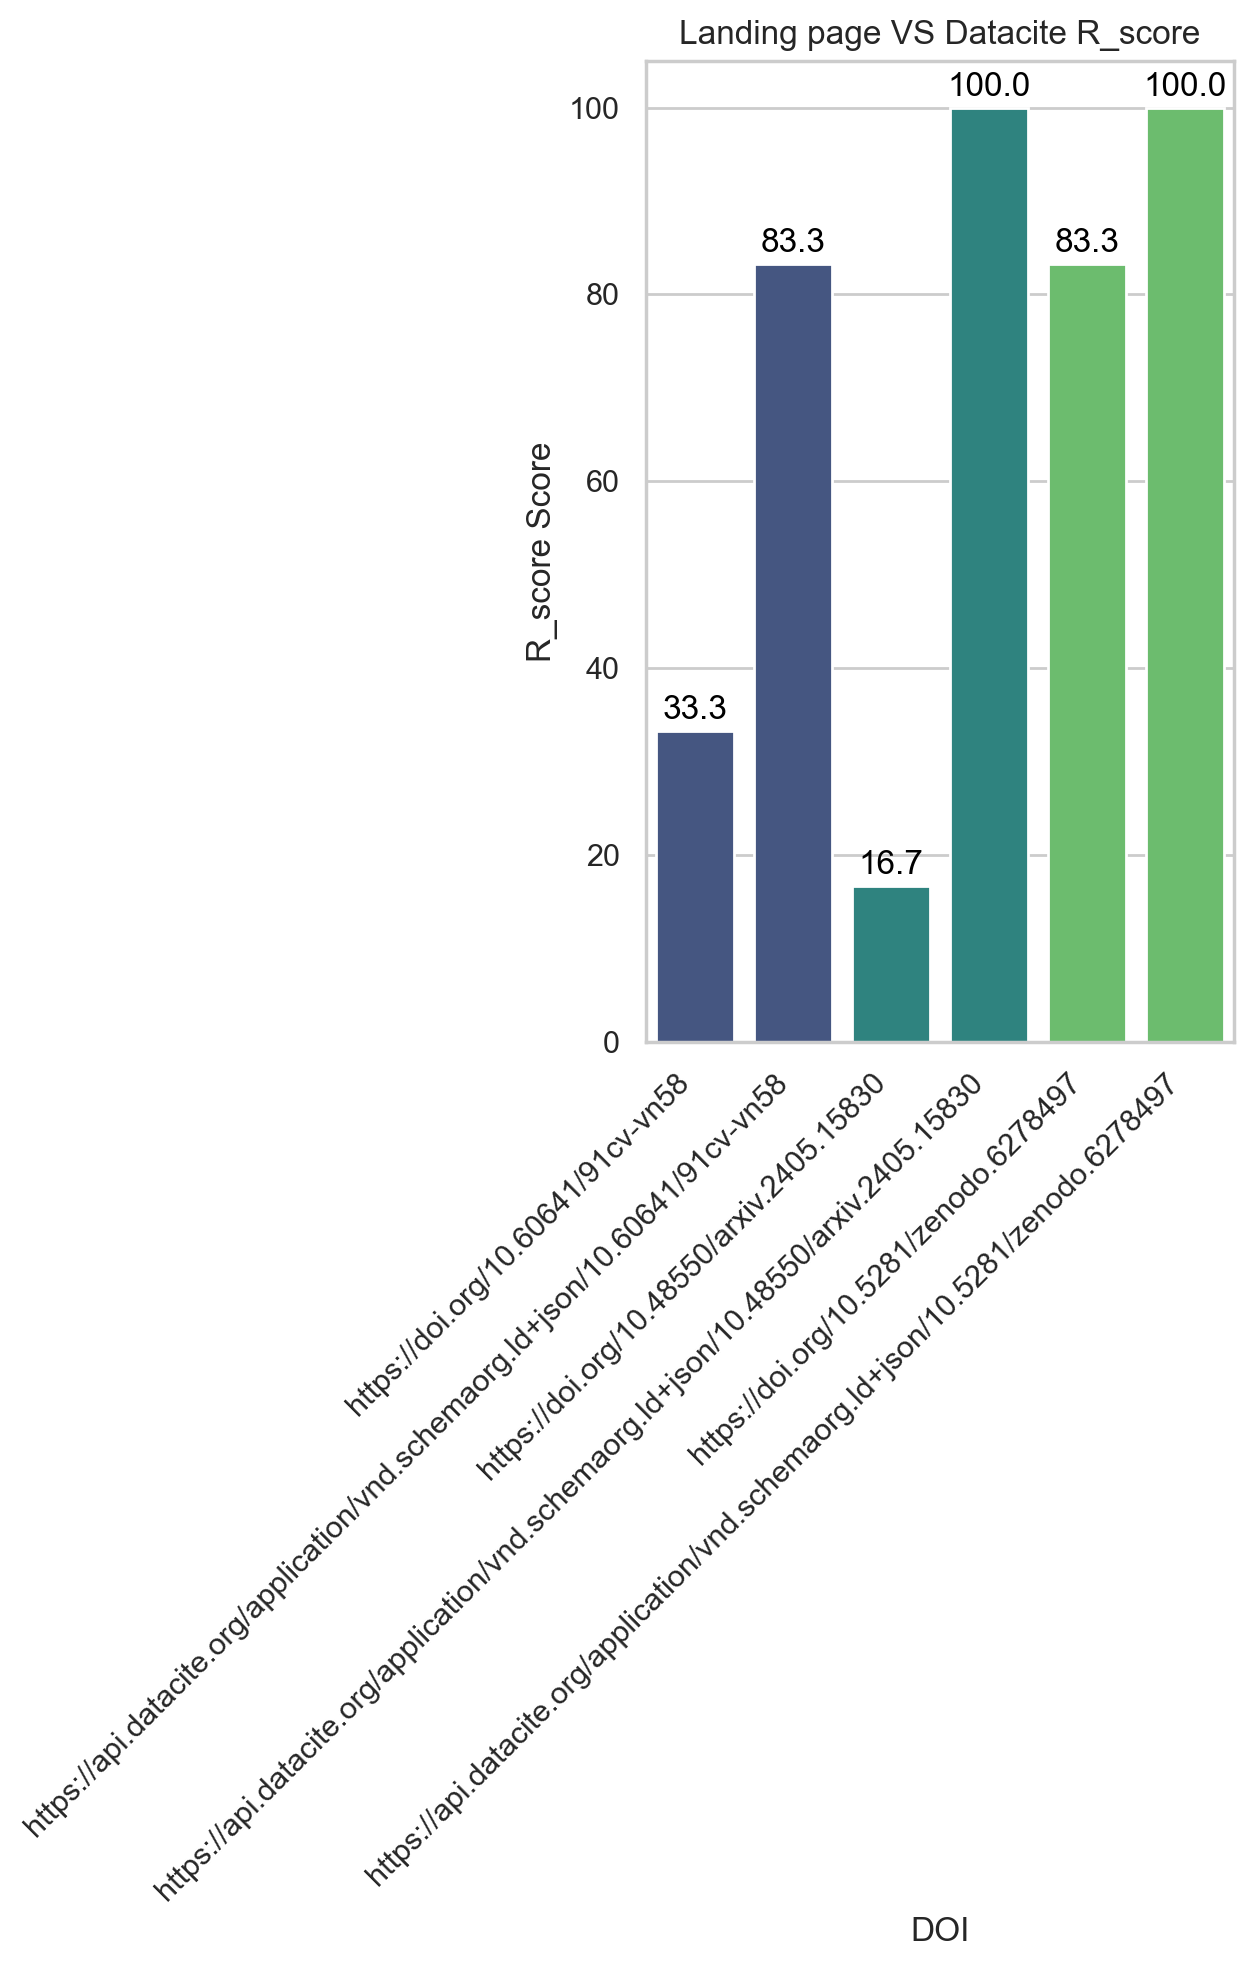

In [49]:
# show the scores for each metric
for metric in ["F_score", "A_score", "I_score", "R_score"]:
    plt.figure(figsize=(6, 10))
    sns.barplot(data=df, x="URL", y=metric, palette="viridis", hue="DOI", legend=False)
    # annotate the bars with the FAIR score
    for index, row in df.iterrows():
        plt.text(
            index,
            row[metric] + 0.5,
            f"{row[metric]}",
            color="black",
            ha="center",
            va="bottom",
        )
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Landing page VS Datacite {metric}")
    plt.xlabel("DOI")
    plt.ylabel(f"{metric} Score")
    plt.tight_layout()
    plt.savefig(f"fair_scores_{metric}.png", dpi=300)
    plt.show()

## Dataset profile validation

In [24]:
FC_profiles = "https://fair-checker.france-bioinformatique.fr/api/inspect/bioschemas_validation"

start = time.time()
# u = DOIs[2]
# u = "https://bio.tools/bwa"
u = "https://zenodo.org/records/15574647"
res = requests.get(url=FC_profiles, params={"url": u})
eval_in_sec = time.time() - start

evaluations = res.json()
print("Evaluation took", eval_in_sec, "seconds")

Evaluation took 8.201245069503784 seconds


In [25]:
#print(evaluations)

In [ ]:
import json

# print(json.dumps(evaluations, indent=2, ensure_ascii=False))

df = pd.DataFrame()

for e in evaluations.keys():
    if "/Dataset" in evaluations[e]["type"]:
        for wa in evaluations[e]["warnings"]:
            df = df.append(
                {"ID": u, "Warning": wa, "Type": evaluations[e]["type"]}, ignore_index=True
            )
        for err in evaluations[e]["errors"]:
            df = df.append(
                {"ID": u, "Error": err, "Type": evaluations[e]["type"]},
                ignore_index=True,
            )
df 

/var/folders/x1/d1nyvpvs0td0htxzsv9x6ggw0000gn/T/ipykernel_59338/933133710.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(
/var/folders/x1/d1nyvpvs0td0htxzsv9x6ggw0000gn/T/ipykernel_59338/933133710.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(
/var/folders/x1/d1nyvpvs0td0htxzsv9x6ggw0000gn/T/ipykernel_59338/933133710.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(
/var/folders/x1/d1nyvpvs0td0htxzsv9x6ggw0000gn/T/ipykernel_59338/933133710.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(
/var/folders/x1/d1nyvpvs0td0htxzsv9x6ggw0000gn/T/ipykernel_59338/933

,ID,Warning,Type,Error
0,https://zenodo.org/records/15574647,https://schema.org/alternateName,https://schema.org/Dataset,NaN
1,https://zenodo.org/records/15574647,https://schema.org/citation,https://schema.org/Dataset,NaN
2,https://zenodo.org/records/15574647,https://schema.org/includedInDataCatalog,https://schema.org/Dataset,NaN
3,https://zenodo.org/records/15574647,https://discovery.biothings.io/view/bioschemas...,https://schema.org/Dataset,NaN
4,https://zenodo.org/records/15574647,https://schema.org/measurementTechnique,https://schema.org/Dataset,NaN
5,https://zenodo.org/records/15574647,https://schema.org/variableMeasured,https://schema.org/Dataset,NaN
6,https://zenodo.org/records/15574647,https://schema.org/version,https://schema.org/Dataset,NaN
7,https://zenodo.org/records/15574647,NaN,https://schema.org/Dataset,https://schema.org/keywords
8,https://zenodo.org/records/15574647,NaN,https://schema.org/Dataset,http://purl.org/dc/terms/conformsTo


In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# count the number of non empty warnings
warns = df["Warning"].apply(lambda x: x if x else None)
print("Number of warnings:", warns.count())

errs = df["Error"].apply(lambda x: x if x else None)
print("Number of Errors:", errs.count())

Number of warnings: 7
Number of Errors: 2


## 7 warnings and 2 errors found.

⚠️ Missing recommended property: https://schema.org/alternateName

⚠️ Missing recommended property: https://schema.org/citation

⚠️ Missing recommended property: https://schema.org/includedInDataCatalog

⚠️ Missing recommended property: https://discovery.biothings.io/view/bioschemas/isBasedOn

⚠️ Missing recommended property: https://schema.org/measurementTechnique

⚠️ Missing recommended property: https://schema.org/variableMeasured

⚠️ Missing recommended property: https://schema.org/version

⛔️ Missing mandatory property: https://schema.org/keywords

⛔️ Missing mandatory property: http://purl.org/dc/terms/conformsTo

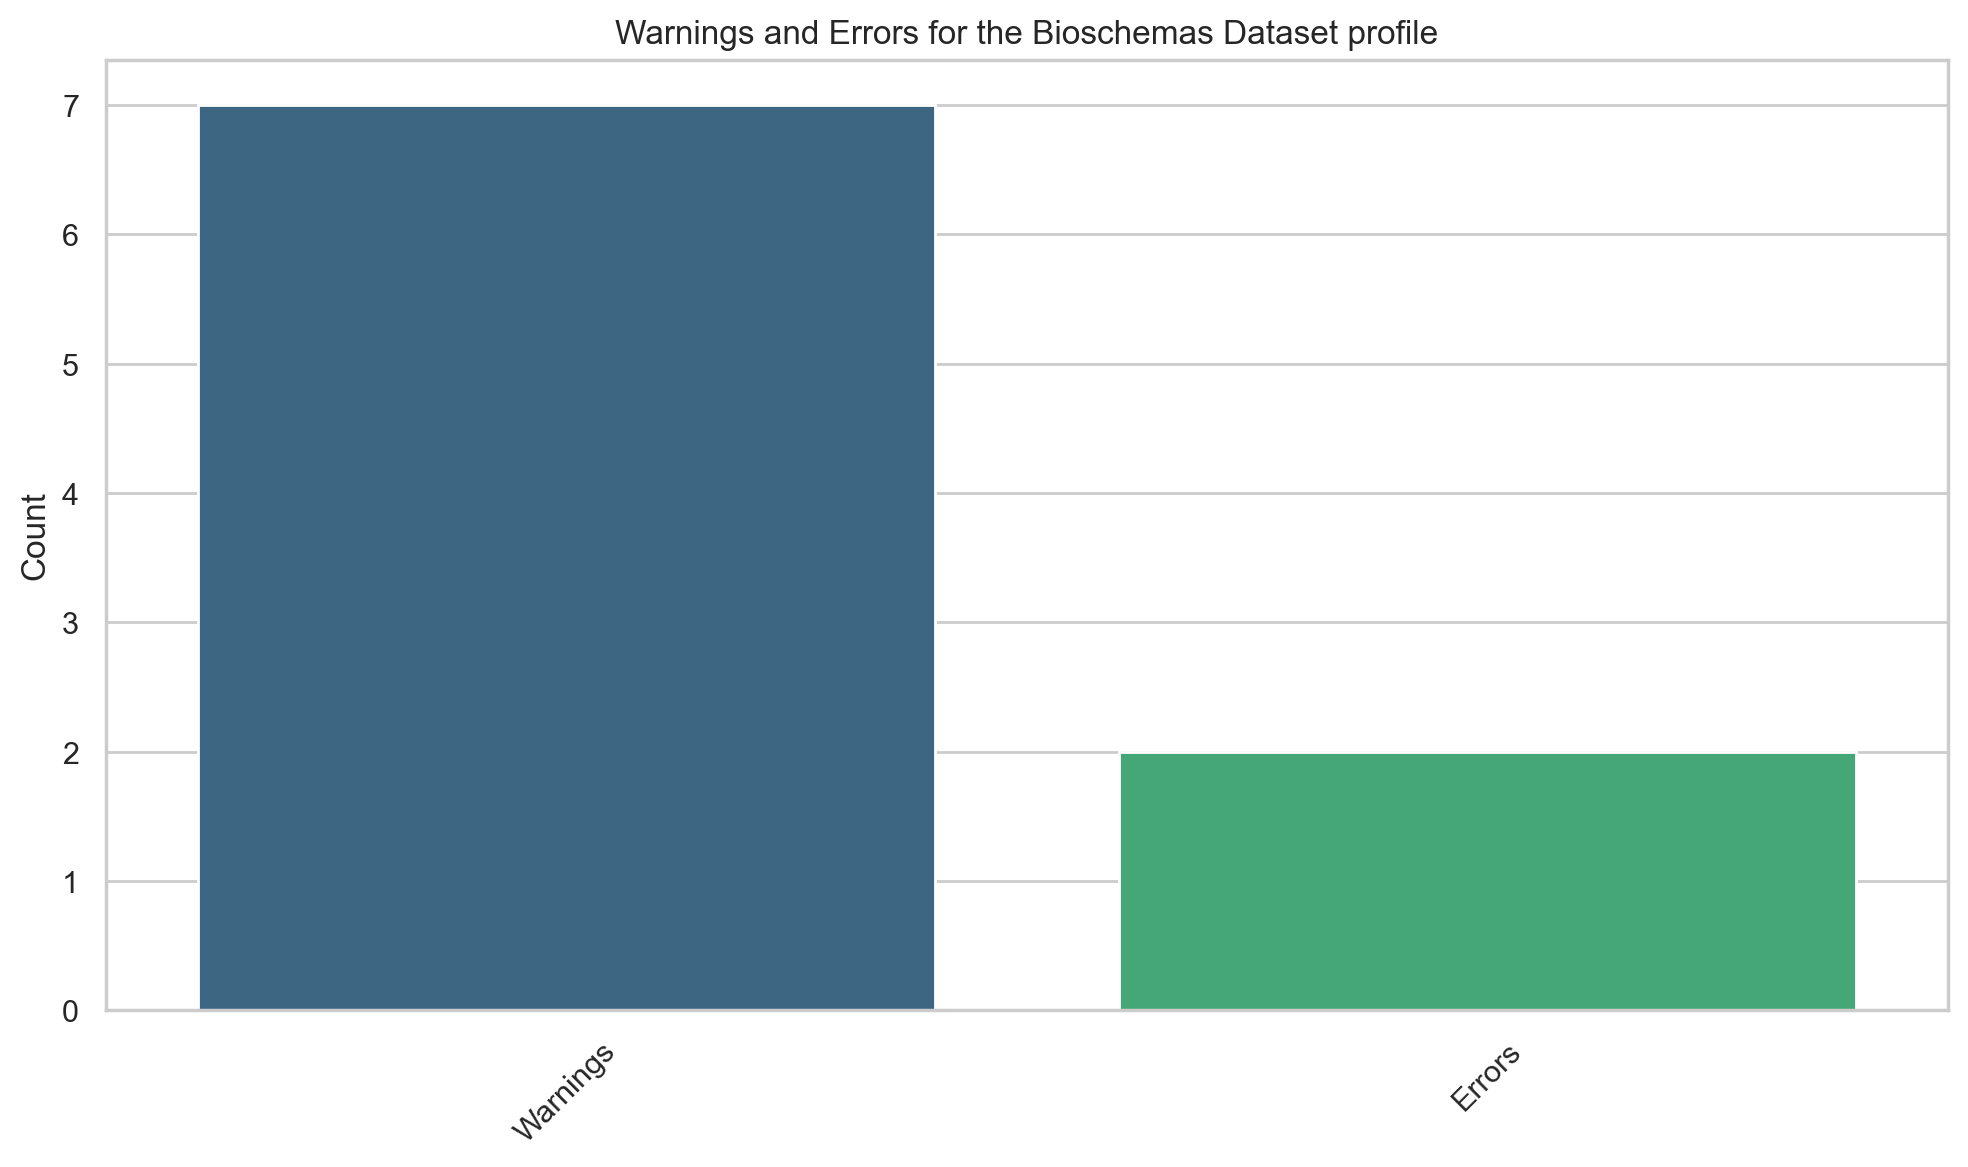

In [ ]:
# display a markdown text with the number of warnings and errors
from IPython.display import display, Markdown
import numpy as np

plt.figure(figsize=(10, 6))

sns.barplot(
    x=["Warnings", "Errors"],
    y=pd.Series([warns.count(), errs.count()]),
    hue=["Warnings", "Errors"],
    palette="viridis",
)
plt.title("Warnings and Errors for the Bioschemas Dataset profile")
# plt.xlabel("Bioschemas Dataset profile conformance")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(Markdown(f"## {warns.count()} warnings and {errs.count()} errors found."))
for w in df["Warning"].unique():
    if w is not np.nan:
        display(Markdown(f"⚠️ Missing recommended property: {w}"))
for err in df["Error"].unique():
    if err is not np.nan:
        display(Markdown(f"⛔️ Missing mandatory property: {err}"))